# L1 SLSQP with reactive warm-restart on the synthetic 2D cases

This notebook runs the **best-performing L1 configuration** from `11_l1-vs-l2-canonical-cases.ipynb` — full-grid SLSQP with the smoothed-L1 objective `Σ √(Δ² + ε²)` (ε = 1e-4), the 2-triangle constraint `triangle_sign_areas2D ≥ 0.01`, and the **reactive warm-restart** (on `not res.success`, perturb σ=0.01 if `status=8` else just resume with extra budget) — across the synthetic 2D test cases. The L2 baseline is also computed per case so the visualisation can show **both objectives side-by-side as two rows per case** (top row = L2, bottom row = L1+warm), with deformation grids and a shared-scale residual heatmap.

Cases included:

| key | shape | first used in |
|---|---|---|
| `01a_10x10_crossing` | 10×10 | `01_vs-central-diff.ipynb` |
| `01b_10x10_opposite` | 10×10 | `01_vs-central-diff.ipynb` |
| `03a_10x10_opposite` | 10×10 | `10_preprocessing-warm-start.ipynb` |
| `03b_10x10_crossing` | 10×10 | `10_preprocessing-warm-start.ipynb` |
| `03c_20x20_opposite` | 20×20 | `01_vs-central-diff.ipynb` |
| `03d_20x20_crossing` | 20×20 | `01_vs-central-diff.ipynb` |

The 20×40 cases (`01c`, `01d`) are deliberately skipped — full-grid SLSQP scales poorly past 20×20 (each 20×20 case takes ~6 min in `11`; 20×40 would be ~25 min each). Anyone needing those should switch to the windowed iterative solver in `dvfopt.core.iterative`.

For each case we report `total_nit` (cold + warm), wall-clock time, `final_L1`, `final_L2`, and `min_TR`. Visualisation is **one figure per case with two rows**:

- **Top row (L2 baseline):** BEFORE | L2 deformation grid | L2 per-pixel residual heatmap.
- **Bottom row (L1 + warm-restart):** label | L1 deformation grid | L1 per-pixel residual heatmap.

The two residual heatmaps share a colour scale so the sparsity-vs-spread contrast is direct.

In [1]:
import os, sys, time, io, contextlib, warnings
sys.path.insert(0, os.path.abspath('../..'))
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian import triangle_sign_areas2D
from dvfopt.jacobian.triangle_sign import _triangle_areas_2d
import test_cases

THRESHOLD = DEFAULT_PARAMS['threshold']
EPS_L1 = 1e-4
print(f'THRESHOLD = {THRESHOLD},  EPS_L1 = {EPS_L1}')

THRESHOLD = 0.01,  EPS_L1 = 0.0001


In [2]:
from dvfopt.core.objective import objective_euc

def _l2(a, b): return float(np.linalg.norm(a - b))
def _l1(a, b): return float(np.abs(a - b).sum())


def _triangle_flat(dy, dx):
    T1, T2 = _triangle_areas_2d(dy, dx)
    return np.concatenate([T1.flatten(), T2.flatten()])

def _pack(phi):
    return np.concatenate([phi[1].flatten(), phi[0].flatten()])

def _unpack(z, H, W):
    pixels = H * W
    return z[pixels:].reshape(H, W), z[:pixels].reshape(H, W)


def _objective(objective, eps=EPS_L1):
    if objective == 'l2':
        def obj(z, z_anchor):
            return objective_euc(z, z_anchor)
    elif objective == 'l1':
        def obj(z, z_anchor):
            diff = z - z_anchor
            s = np.sqrt(diff * diff + eps * eps)
            return float(s.sum()), diff / s
    else:
        raise ValueError(objective)
    return obj


def run_slsqp(phi_anchor, objective, max_iter, threshold=THRESHOLD,
              warm_start=True, warm_max_iter=2000, warm_ftol=1e-10,
              warm_sigma=0.01, warm_seed=123, eps=EPS_L1):
    """SLSQP with smoothed-L1 / L2 objective and the reactive warm-restart from notebook 11.

    Initial run: SLSQP from `phi_anchor` for up to `max_iter` iterations.
    On `not res.success`: if `status == 8` (line-search stall) perturb iterate by
    Gaussian sigma=warm_sigma; otherwise resume from current iterate. Either way
    run for up to `warm_max_iter` more iterations with tighter `ftol`.
    """
    _, H, W = phi_anchor.shape
    z_anchor = _pack(phi_anchor)
    obj = _objective(objective, eps=eps)

    def constr(z):
        dy, dx = _unpack(z, H, W)
        return _triangle_flat(dy, dx)

    nl = NonlinearConstraint(constr, lb=threshold, ub=np.inf)

    t0 = time.time()
    res = minimize(lambda z: obj(z, z_anchor),
                   z_anchor.copy(), jac=True, method='SLSQP',
                   constraints=[nl],
                   options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False})
    cold_nit, cold_t = res.nit, time.time() - t0
    cold_success, cold_status = bool(res.success), int(res.status)

    warm_fired, warm_reason, warm_nit, warm_t = False, '', 0, 0.0
    if warm_start and not res.success:
        warm_fired = True
        if res.status == 8:
            rng = np.random.default_rng(warm_seed)
            z_warm = res.x + rng.normal(scale=warm_sigma, size=res.x.shape)
            warm_reason = f'status={res.status} (line-search stall); perturbed sigma={warm_sigma}'
        else:
            z_warm = res.x.copy()
            warm_reason = f'status={res.status} (resume with extra budget)'
        t1 = time.time()
        res = minimize(lambda z: obj(z, z_anchor),
                       z_warm, jac=True, method='SLSQP',
                       constraints=[nl],
                       options={'maxiter': warm_max_iter, 'ftol': warm_ftol, 'disp': False})
        warm_nit, warm_t = res.nit, time.time() - t1

    elapsed = time.time() - t0
    dy_out, dx_out = _unpack(res.x, H, W)
    phi_final = np.stack([dy_out, dx_out])
    tri = triangle_sign_areas2D(phi_final)
    return {
        'objective': objective,
        'phi': phi_final,
        'min_tr': float(tri.min()),
        'n_neg_tr': int((tri <= 0).sum()),
        'final_l2': _l2(phi_final, phi_anchor),
        'final_l1': _l1(phi_final, phi_anchor),
        'nit': cold_nit + warm_nit,
        't': elapsed,
        'cold_nit': cold_nit, 'cold_t': cold_t,
        'cold_success': cold_success, 'cold_status': cold_status,
        'warm_fired': warm_fired, 'warm_nit': warm_nit, 'warm_t': warm_t,
        'warm_reason': warm_reason,
        'success': bool(res.success),
        'status': int(res.status),
    }


def plot_warped_grid(ax, phi, title, highlight_folds=True, fontsize=8):
    dy, dx = phi[0], phi[1]
    H, W = dy.shape
    yy, xx = np.mgrid[:H, :W]
    gx, gy = xx + dx, yy + dy
    for i in range(H):
        ax.plot(xx[i], yy[i], color='#f0f0f0', lw=0.4)
    for j in range(W):
        ax.plot(xx[:, j], yy[:, j], color='#f0f0f0', lw=0.4)
    for i in range(H):
        ax.plot(gx[i], gy[i], color='#5b7fb5', lw=0.8)
    for j in range(W):
        ax.plot(gx[:, j], gy[:, j], color='#5b7fb5', lw=0.8)
    if highlight_folds:
        tri = triangle_sign_areas2D(phi)
        for (cy, cx) in np.argwhere(tri.min(axis=0) <= 0):
            px = [gx[cy, cx], gx[cy, cx+1], gx[cy+1, cx+1], gx[cy+1, cx], gx[cy, cx]]
            py = [gy[cy, cx], gy[cy, cx+1], gy[cy+1, cx+1], gy[cy+1, cx], gy[cy, cx]]
            ax.plot(px, py, color='#1565c0', lw=1.4)
    ax.set_aspect('equal'); ax.invert_yaxis()
    ax.set_title(title, fontsize=fontsize)
    ax.set_xticks([]); ax.set_yticks([])


def per_pixel_residual_l2(phi_final, phi_anchor):
    return np.linalg.norm(phi_final - phi_anchor, axis=0)

In [3]:
def _silent_make(case_key):
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        df, _, _ = test_cases.make_deformation(case_key)
    return df[1:, 0]  # (3, 1, H, W) -> (2, H, W) channels [dy, dx]

# (case_key, cold_max_iter, warm_max_iter)
# Budgets match notebook 11: 10x10 cases need ~400 iter to converge L1+warm,
# 20x20 cases hit the 1080-iter cap before formally converging but reach
# feasibility (min_TR = +0.010) and a much-reduced L1.
CASE_DEFS = [
    ('01a_10x10_crossing',   50, 1000),
    ('01b_10x10_opposite',   50, 1000),
    ('03a_10x10_opposite',   50, 1000),
    ('03b_10x10_crossing',   50, 1000),
    ('03c_20x20_opposite',   80, 1200),
    ('03d_20x20_crossing',   80, 1200),
]
CASES = [(k, _silent_make(k), it_cold, it_warm) for (k, it_cold, it_warm) in CASE_DEFS]

for name, phi, it_cold, it_warm in CASES:
    tri = triangle_sign_areas2D(phi)
    print(f'{name:<22s}  shape={phi.shape}  n_neg_tri={int((tri<=0).sum()):>4d}  '
          f'min_tr={float(tri.min()):+.3f}  '
          f'cold_max={it_cold:>4d}  warm_max={it_warm:>4d}')

01a_10x10_crossing      shape=(2, 10, 10)  n_neg_tri=  24  min_tr=-0.744  cold_max=  50  warm_max=1000
01b_10x10_opposite      shape=(2, 10, 10)  n_neg_tri=  10  min_tr=-0.587  cold_max=  50  warm_max=1000
03a_10x10_opposite      shape=(2, 10, 10)  n_neg_tri=  23  min_tr=-0.814  cold_max=  50  warm_max=1000
03b_10x10_crossing      shape=(2, 10, 10)  n_neg_tri=  28  min_tr=-0.700  cold_max=  50  warm_max=1000
03c_20x20_opposite      shape=(2, 20, 20)  n_neg_tri=  58  min_tr=-0.809  cold_max=  80  warm_max=1200
03d_20x20_crossing      shape=(2, 20, 20)  n_neg_tri=  72  min_tr=-0.740  cold_max=  80  warm_max=1200


In [4]:
results = {}
overall_t0 = time.time()
for name, phi, it_cold, it_warm in CASES:
    print(f'>>> {name}  (cold cap={it_cold}, warm extra={it_warm})', flush=True)
    t_case = time.time()

    # L2 baseline (cold; warm-restart enabled but typically does not fire for L2).
    r_l2 = run_slsqp(phi, 'l2', max_iter=it_cold, warm_start=True,
                     warm_max_iter=it_warm)
    print(f'    L2  ok={r_l2["success"]!s:<5s} nit={r_l2["nit"]:5d}  '
          f't={r_l2["t"]:7.2f}s  '
          f'final_L2={r_l2["final_l2"]:7.3f}  final_L1={r_l2["final_l1"]:8.3f}  '
          f'min_TR={r_l2["min_tr"]:+.3f}  '
          f'{"warm fired" if r_l2["warm_fired"] else "no warm"}', flush=True)

    # L1 with reactive warm-restart - the focus of this notebook.
    r_l1 = run_slsqp(phi, 'l1', max_iter=it_cold, warm_start=True,
                     warm_max_iter=it_warm)
    warm_str = (f'warm fired ({r_l1["warm_reason"]})'
                if r_l1['warm_fired'] else 'no warm')
    print(f'    L1  ok={r_l1["success"]!s:<5s} nit={r_l1["nit"]:5d}  '
          f't={r_l1["t"]:7.2f}s  '
          f'final_L1={r_l1["final_l1"]:8.3f}  final_L2={r_l1["final_l2"]:7.3f}  '
          f'min_TR={r_l1["min_tr"]:+.3f}  {warm_str}', flush=True)

    results[name] = {'phi': phi, 'l2': r_l2, 'l1': r_l1,
                     'cold_max_iter': it_cold, 'warm_max_iter': it_warm}
    print(f'<<< case done in {time.time()-t_case:.1f}s', flush=True)

print(f'\nALL CASES DONE in {time.time()-overall_t0:.1f}s')

>>> 01a_10x10_crossing  (cold cap=50, warm extra=1000)


    L2  ok=True  nit=   34  t=   0.33s  final_L2=  3.043  final_L1=   6.946  min_TR=+0.010  no warm


    L1  ok=True  nit=  381  t=   3.64s  final_L1=   6.641  final_L2=  3.045  min_TR=+0.010  warm fired (status=9 (resume with extra budget))


<<< case done in 4.0s


>>> 01b_10x10_opposite  (cold cap=50, warm extra=1000)


...

>>> 03d_20x20_crossing  (cold cap=80, warm extra=1200)


    L2  ok=True  nit=   43  t=  12.25s  final_L2=  7.376  final_L1=  80.431  min_TR=+0.010  no warm


    L1  ok=False nit= 1280  t= 392.68s  final_L1=  46.256  final_L2=  8.000  min_TR=+0.010  warm fired (status=9 (resume with extra budget))


<<< case done in 404.9s



ALL CASES DONE in 785.3s


In [5]:
print(f"{'case':<22s}  {'shape':<7s}  {'obj':<3s}  {'ok':>5s}  {'st':>3s}  "
      f"{'nit':>5s}  {'t(s)':>7s}  {'final L1':>9s}  {'final L2':>9s}  "
      f"{'min_TR':>8s}  {'warm':>5s}")
print('-' * 110)
for name, phi, _, _ in CASES:
    rr = results[name]
    shape_str = f'{phi.shape[1]}x{phi.shape[2]}'
    for obj_label in ('l2', 'l1'):
        r = rr[obj_label]
        print(f'{name:<22s}  {shape_str:<7s}  {obj_label.upper():<3s}  '
              f'{str(r["success"]):>5s}  {r["status"]:>3d}  '
              f'{r["nit"]:>5d}  {r["t"]:>7.2f}  '
              f'{r["final_l1"]:>9.3f}  {r["final_l2"]:>9.3f}  '
              f'{r["min_tr"]:>+8.3f}  '
              f'{str(r["warm_fired"]):>5s}')

case                    shape    obj     ok   st    nit     t(s)   final L1   final L2    min_TR   warm
--------------------------------------------------------------------------------------------------------------
01a_10x10_crossing      10x10    L2    True    0     34     0.33      6.946      3.043    +0.010  False
01a_10x10_crossing      10x10    L1    True    0    381     3.64      6.641      3.045    +0.010   True
01b_10x10_opposite      10x10    L2    True    0      9     0.08      4.024      1.654    +0.010  False
01b_10x10_opposite      10x10    L1    True    0    436     3.90      3.536      2.020    +0.010   True
03a_10x10_opposite      10x10    L2    True    0     18     0.15     10.550      2.334    +0.010  False
03a_10x10_opposite      10x10    L1    True    0    437     4.07      7.093      2.801    +0.010   True
03b_10x10_crossing      10x10    L2    True    0     35     0.34     21.719      4.443    +0.010  False
03b_10x10_crossing      10x10    L1    True    0    493  

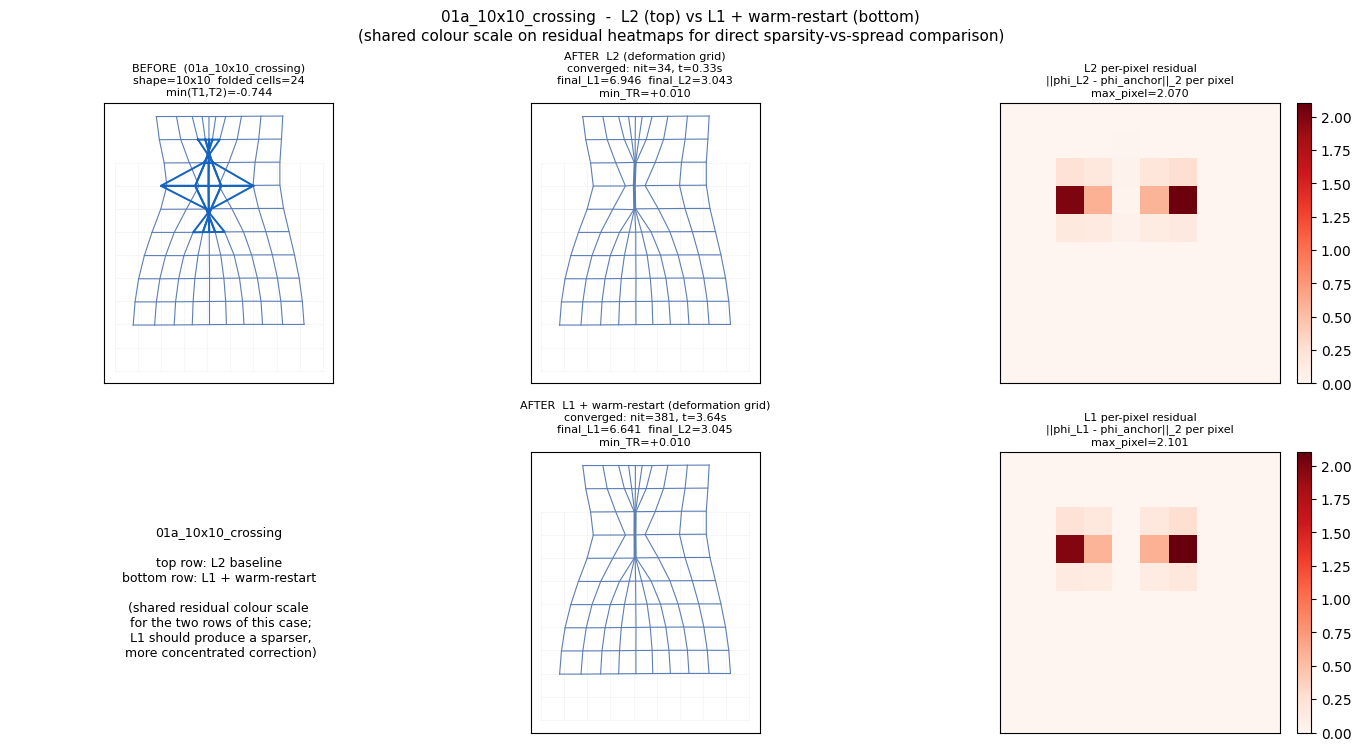

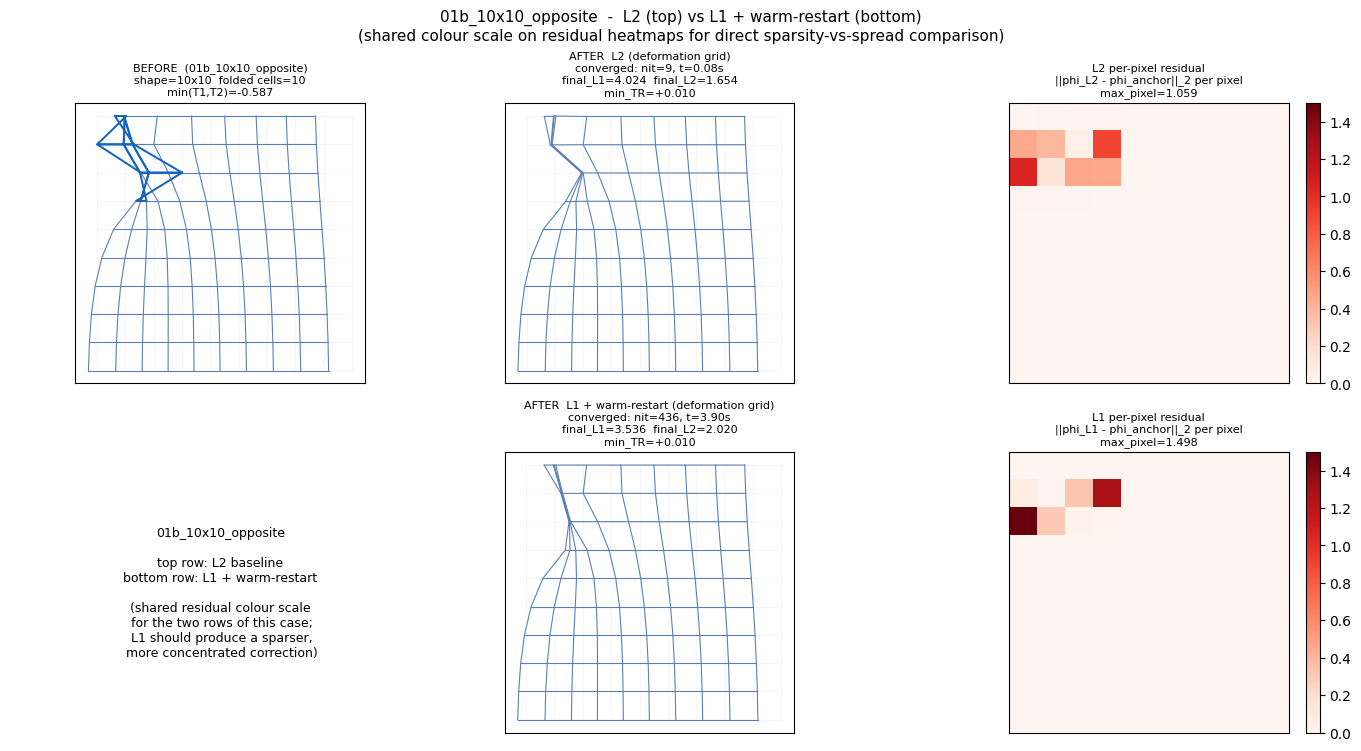

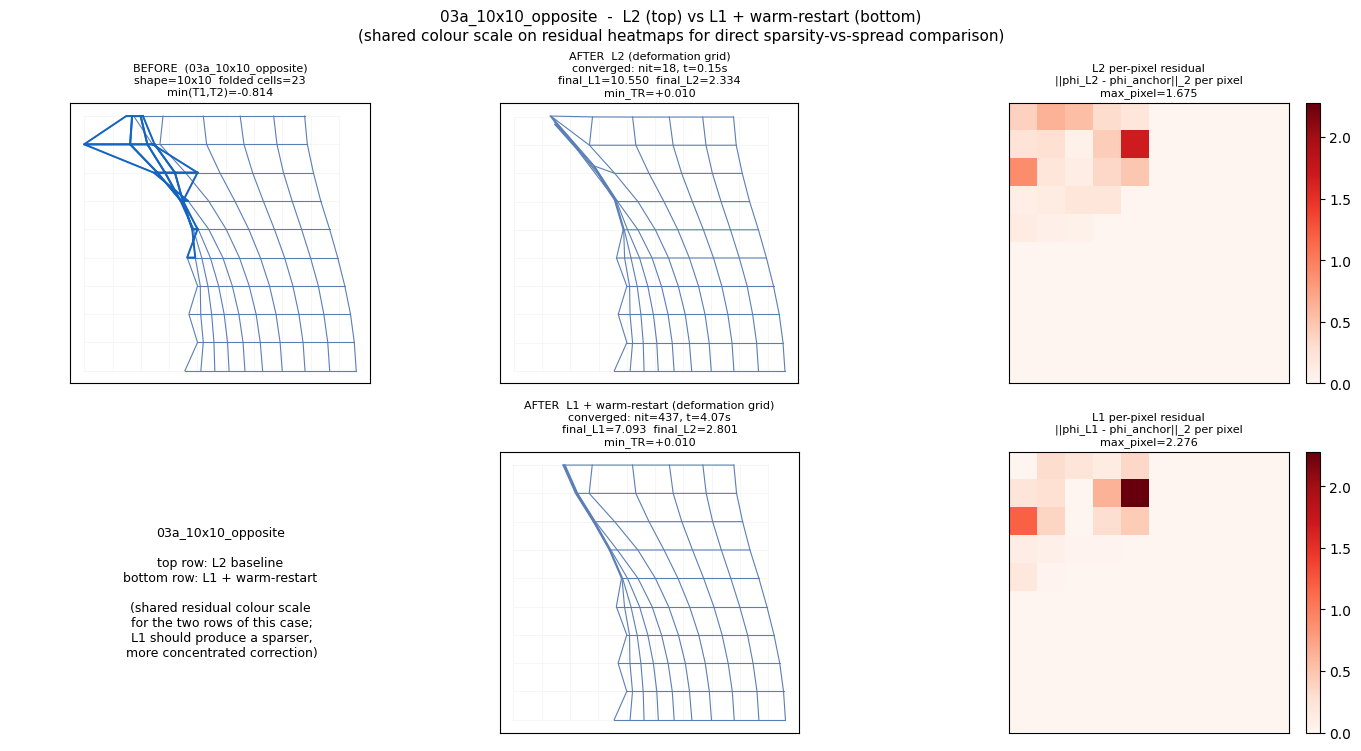

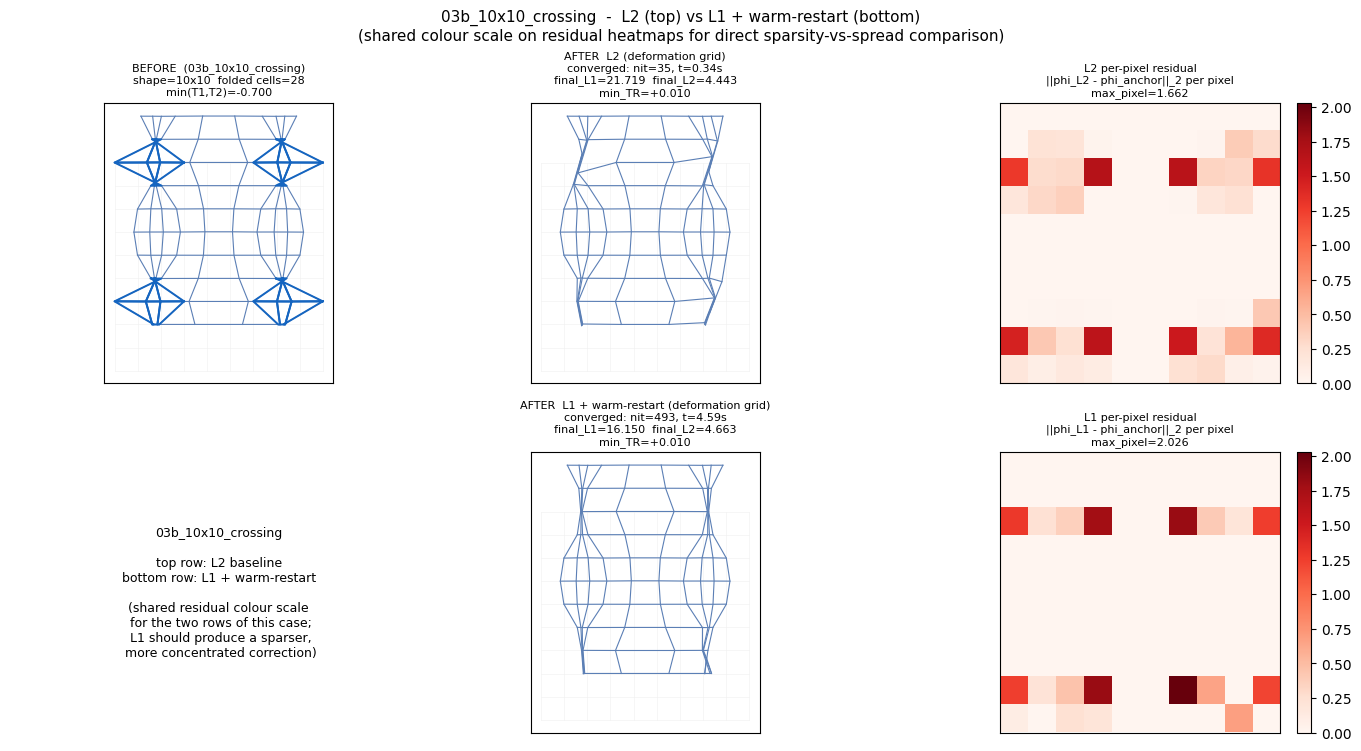

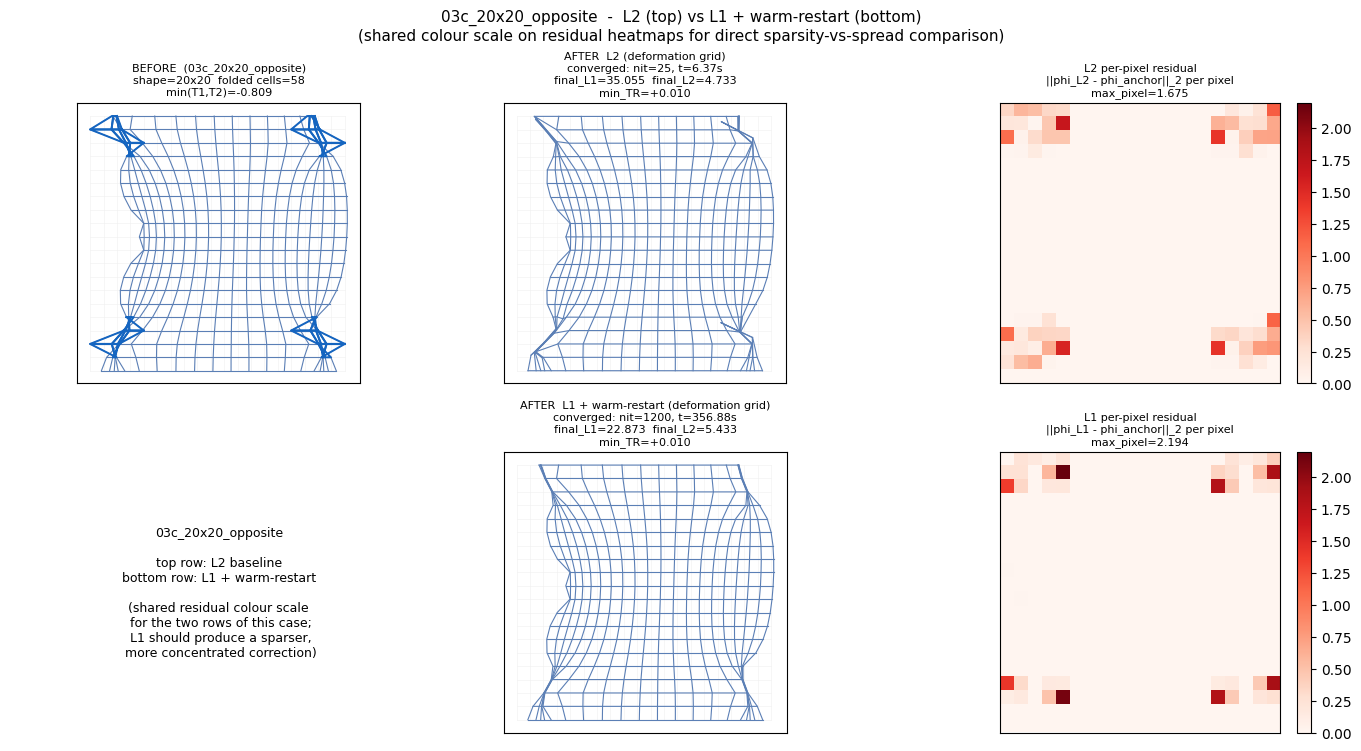

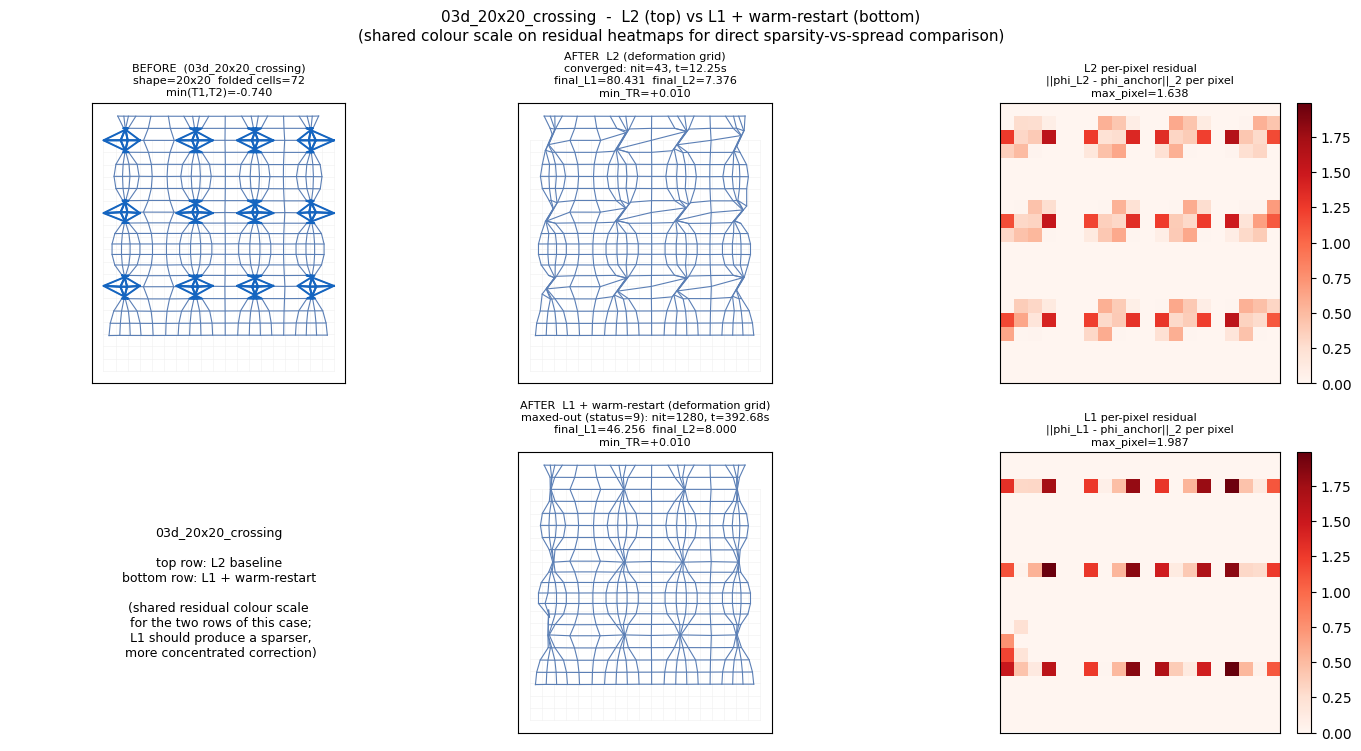

In [6]:
# Per-case figure: top row = L2 baseline, bottom row = L1 + reactive warm-restart.
# Columns: BEFORE | warped deformation grid | per-pixel L2 residual heatmap.
# Residual colour scale is shared across the two rows of the same case so the
# sparsity-vs-spread contrast is visually direct.
for name, phi, _, _ in CASES:
    rr = results[name]
    r_l2 = rr['l2']
    r_l1 = rr['l1']
    res_l2 = per_pixel_residual_l2(r_l2['phi'], phi)
    res_l1 = per_pixel_residual_l2(r_l1['phi'], phi)
    vmax = max(float(res_l2.max()), float(res_l1.max()), 1e-6)

    n_orig = int((triangle_sign_areas2D(phi) <= 0).sum())
    orig_min_tr = float(triangle_sign_areas2D(phi).min())

    fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.4), layout='constrained')

    # ===== Top row: L2 baseline =====
    plot_warped_grid(
        axes[0, 0], phi,
        f'BEFORE  ({name})\n'
        f'shape={phi.shape[1]}x{phi.shape[2]}  folded cells={n_orig}\n'
        f'min(T1,T2)={orig_min_tr:+.3f}',
    )

    status_l2 = 'converged' if r_l2['success'] else f'maxed-out (status={r_l2["status"]})'
    plot_warped_grid(
        axes[0, 1], r_l2['phi'],
        f'AFTER  L2 (deformation grid)\n'
        f'{status_l2}: nit={r_l2["nit"]}, t={r_l2["t"]:.2f}s\n'
        f'final_L1={r_l2["final_l1"]:.3f}  final_L2={r_l2["final_l2"]:.3f}\n'
        f'min_TR={r_l2["min_tr"]:+.3f}',
    )

    im0 = axes[0, 2].imshow(res_l2, cmap='Reds', vmin=0, vmax=vmax)
    axes[0, 2].set_title(
        f'L2 per-pixel residual\n'
        f'||phi_L2 - phi_anchor||_2 per pixel\n'
        f'max_pixel={res_l2.max():.3f}', fontsize=8,
    )
    axes[0, 2].set_xticks([]); axes[0, 2].set_yticks([])
    fig.colorbar(im0, ax=axes[0, 2], fraction=0.046, pad=0.04)

    # ===== Bottom row: L1 + reactive warm-restart =====
    axes[1, 0].axis('off')
    axes[1, 0].text(
        0.5, 0.5,
        f'{name}\n\n'
        f'top row: L2 baseline\n'
        f'bottom row: L1 + warm-restart\n\n'
        f'(shared residual colour scale\n'
        f' for the two rows of this case;\n'
        f' L1 should produce a sparser,\n'
        f' more concentrated correction)',
        ha='center', va='center', fontsize=9, transform=axes[1, 0].transAxes,
    )

    status_l1 = 'converged' if r_l1['success'] else f'maxed-out (status={r_l1["status"]})'
    plot_warped_grid(
        axes[1, 1], r_l1['phi'],
        f'AFTER  L1 + warm-restart (deformation grid)\n'
        f'{status_l1}: nit={r_l1["nit"]}, t={r_l1["t"]:.2f}s\n'
        f'final_L1={r_l1["final_l1"]:.3f}  final_L2={r_l1["final_l2"]:.3f}\n'
        f'min_TR={r_l1["min_tr"]:+.3f}',
    )

    im1 = axes[1, 2].imshow(res_l1, cmap='Reds', vmin=0, vmax=vmax)
    axes[1, 2].set_title(
        f'L1 per-pixel residual\n'
        f'||phi_L1 - phi_anchor||_2 per pixel\n'
        f'max_pixel={res_l1.max():.3f}', fontsize=8,
    )
    axes[1, 2].set_xticks([]); axes[1, 2].set_yticks([])
    fig.colorbar(im1, ax=axes[1, 2], fraction=0.046, pad=0.04)

    plt.suptitle(
        f'{name}  -  L2 (top) vs L1 + warm-restart (bottom)\n'
        f'(shared colour scale on residual heatmaps for direct sparsity-vs-spread comparison)',
        fontsize=11,
    )
    plt.show()

## Notes

- **Trigger.** L1 cold runs typically end with `status=9` (max-iter reached). The reactive warm-restart catches that (we use the `not res.success` trigger from `11`, not the original `status=8`-only trigger from `02_optimization.ipynb`) and resumes with a much larger budget and tighter `ftol`.
- **No perturbation.** Because the failure mode is iter-exhaustion not line-search degeneracy, the resume is a plain "give it more iterations" — the σ=0.01 Gaussian perturb branch doesn't fire on these cases (it would for `status=8`, e.g. the bowtie under L1 in `10`).
- **What 20×20 cases reach.** Per `11`, even with a 1080-iter total budget the 20×20 cases hit the cap before formally converging (`success=False`), but they reach **feasibility** (`min_TR = +0.010`) and a much lower `final_L1` than the cold result. We use the same budget here.
- **Read the residual heatmaps.** L1 should produce *concentrated* corrections — a few pixels with high per-pixel magnitude rather than a smooth spread (which is what L2 produces; see notebook `11` for the side-by-side).

For the bigger picture (L1 vs L2 comparison, sparsity-vs-spread, when the warm-restart actually fires), see `11_l1-vs-l2-canonical-cases.ipynb`. For preprocessing-as-warm-start ideas that proactively trim the L1 budget further, see `10_preprocessing-warm-start.ipynb`.